# Q2 — Instrument, Sweep & Compare MLflow Runs (MLP on MNIST)
### AI Operations (DA3408) — Module 1 Assignment | Question 2

**Objective:** take the un-instrumented MLP training script, add MLflow tracking to it, sweep two
hyperparameters, and then compare every run programmatically — table, learning curves, and effect
sizes — instead of eyeballing the UI.

**The instrumented script — [`train.py`](train.py) — is part of the deliverable, not a helper.**
It holds the MLflow calls: `set_experiment()`, `start_run()`, 9 `log_param()` calls, per-epoch
`log_metric()` with `step=`, 6 summary metrics, `log_figure()` and `sklearn.log_model()`. It also
runs standalone for a single configuration:
```bash
python train.py --learning_rate 0.01 --batch_size 32 --epochs 30
```
This notebook is the harness: it drives that script across the grid and reads the results back out
of the tracking store.

**Steps:**
0. Connect to the tracking server and import the instrumented trainer.
1. Load MNIST once so every run sees the identical train/validation split.
2. Fix the sweep grid: `learning_rate` × `batch_size`, everything else held constant.
3. Run the sweep — one MLflow run per combination, logged by `train.run_experiment()`.
4. Pull all runs back with `mlflow.search_runs()` and export the comparison table.
5. Plot `train_loss` and `val_accuracy` against epoch for the best and worst run.
6. Quantify which hyperparameter has the larger effect.
7. Confirm the ranking in the MLflow UI **Compare** view.

**Deliverables:** the instrumented `train.py`, the comparison table (`results/runs_export.csv`), the
best-vs-worst curve plots, a screenshot of the Compare view, and a 150–250 word written analysis.

> **Prerequisite:** a local MLflow Tracking Server must already be running, started **from this
> directory** so the store lands next to the notebook:
> ```bash
> cd q2_mlflow_mnist
> mlflow server --backend-store-uri sqlite:///mlflow.db \
>     --default-artifact-root ./mlruns --host 0.0.0.0 --port 5000 --allowed-hosts "*"
> ```
> Run that command in a separate terminal *before* executing the cells below, then leave it running.

## Step 0 — Setup
Point MLflow at the local tracking server and import the instrumented trainer from
[`train.py`](train.py) — `load_mnist()` for the data and `run_experiment()` for one tracked run.
The matplotlib backend must be `inline` (not `agg`) or the curve plots in Step 5 render nothing:
`train.py` sets `agg` for headless CLI runs, so it is worth asserting here.

In [1]:
import matplotlib.pyplot as plt
import mlflow
import pandas as pd
from IPython.display import display
from mlflow.tracking import MlflowClient

from train import load_mnist, run_experiment

%matplotlib inline

TRACKING_URI = "http://localhost:5000"
EXPERIMENT_NAME = "mnist-mlp"

mlflow.set_tracking_uri(TRACKING_URI)
client = MlflowClient()

print("tracking URI      :", mlflow.get_tracking_uri())
print("matplotlib backend:", plt.get_backend(), "(must NOT be 'agg')")

tracking URI      : http://localhost:5000
matplotlib backend: inline (must NOT be 'agg')


## Step 1 — Load MNIST once
Every run in the sweep must be compared on the same data, so the split is built once here and passed
into each run. 10,000 training images and a fixed 2,000-image stratified validation set, `seed=42`.

In [2]:
data = load_mnist(10000, 42)
X_train, X_val, y_train, y_val = data

print("X_train:", X_train.shape)
print("X_val  :", X_val.shape)
print("y_train:", y_train.shape)
print("y_val  :", y_val.shape)

X_train: (10000, 784)
X_val  : (2000, 784)
y_train: (10000,)
y_val  : (2000,)


## Step 2 — The sweep grid


| Hyperparameter | Values swept |
| --- | --- |
| `learning_rate` | 0.001, 0.01, 0.1 |
| `batch_size` | 32, 256 |

Held constant:

| Held constant | Value |
| --- | --- |
| `hidden_size` | 128 |
| `epochs` | 30 |
| `n_train` | 10000 |
| `seed` | 42 |
| solver | `adam` |
| validation set | 2000 samples (same split for every run) |

## Step 3 — Run the sweep
One `mlflow.start_run()` per grid point — 3 learning rates × 2 batch sizes = 6 runs. Each run logs
9 parameters, per-epoch `train_loss` / `train_accuracy` / `val_accuracy` (30 steps each), 6 summary
metrics, the loss-vs-accuracy figure, and the fitted model.

In [3]:
%%time

LEARNING_RATES = [0.001, 0.01, 0.1]
BATCH_SIZES = [32, 256]

results = []

for lr in LEARNING_RATES:
    for bs in BATCH_SIZES:
        print(f"→ starting learning_rate={lr}, batch_size={bs} ...", flush=True)
        run_id, val_acc = run_experiment(
            learning_rate=lr,
            batch_size=bs,
            hidden_size=128,
            epochs=30,
            n_train=10000,
            seed=42,
            data=data,
        )
        results.append((lr, bs, run_id, val_acc))
        print(
            f"✓ done   learning_rate={lr}, batch_size={bs} → "
            f"final_val_accuracy={val_acc:.4f}  (run_id={run_id})\n",
            flush=True,
        )

print(f"Sweep complete: {len(results)} runs logged to {EXPERIMENT_NAME!r}")

→ starting learning_rate=0.001, batch_size=32 ...
epoch   1/30  train_loss=0.5410  train_acc=0.9289  val_acc=0.9080
epoch   2/30  train_loss=0.2571  train_acc=0.9483  val_acc=0.9305
epoch   3/30  train_loss=0.1897  train_acc=0.9626  val_acc=0.9405
epoch   4/30  train_loss=0.1448  train_acc=0.9730  val_acc=0.9430
epoch   5/30  train_loss=0.1121  train_acc=0.9824  val_acc=0.9450
epoch   6/30  train_loss=0.0873  train_acc=0.9856  val_acc=0.9445
epoch   7/30  train_loss=0.0678  train_acc=0.9894  val_acc=0.9475
epoch   8/30  train_loss=0.0523  train_acc=0.9924  val_acc=0.9470
epoch   9/30  train_loss=0.0397  train_acc=0.9937  val_acc=0.9485
epoch  10/30  train_loss=0.0302  train_acc=0.9946  val_acc=0.9490
epoch  11/30  train_loss=0.0233  train_acc=0.9950  val_acc=0.9490
epoch  12/30  train_loss=0.0188  train_acc=0.9943  val_acc=0.9455
epoch  13/30  train_loss=0.0149  train_acc=0.9956  val_acc=0.9485
epoch  14/30  train_loss=0.0140  train_acc=0.9967  val_acc=0.9445
epoch  15/30  train_loss=0

## Step 4 — Compare the runs with `mlflow.search_runs()`
No need to open the UI to rank them — query the tracking store directly, ordered by
`final_val_accuracy`, and export the table as the deliverable.

In [ ]:
runs_raw = mlflow.search_runs(
    experiment_names=[EXPERIMENT_NAME],
    order_by=["metrics.final_val_accuracy DESC"],
)

WANTED = [
    "run_id",
    "tags.mlflow.runName",
    "params.learning_rate",
    "params.batch_size",
    "metrics.final_train_loss",
    "metrics.final_val_accuracy",
    "metrics.best_val_accuracy",
    "metrics.overfit_gap",
]
columns = [c for c in WANTED if c in runs_raw.columns]
missing = [c for c in WANTED if c not in runs_raw.columns]
if missing:
    print("note — columns absent from the search result:", missing)

runs_table = runs_raw[columns].reset_index(drop=True)

display(runs_table)

runs_table.to_csv("results/runs_export.csv", index=False)
print(f"\nWrote results/runs_export.csv  ({len(runs_table)} rows)")

,run_id,tags.mlflow.runName,params.learning_rate,params.batch_size,metrics.final_train_loss,metrics.final_val_accuracy,metrics.best_val_accuracy,metrics.overfit_gap
0,5b0231ae1d0a4eaaa62a6a83bacdaa98,mlp-lr0.001-bs32,0.001,32,0.005303,0.9525,0.9545,0.0463
1,ac4478f73c6346fbaf06b29c798aeba8,mlp-lr0.001-bs256,0.001,256,0.023113,0.9470,0.9470,0.0492
2,6eb100abb4d2479e97f630536fc4a2cf,mlp-lr0.01-bs256,0.01,256,0.028781,0.9465,0.9530,0.0440
3,d22d878da9aa4f5c8b021f6c4a608ac9,mlp-lr0.01-bs32,0.01,32,0.093162,0.9275,0.9420,0.0466
4,71eb7a4fc88441b880afe876f15cdc99,mlp-lr0.1-bs256,0.1,256,0.538711,0.8160,0.8795,0.0244
5,bc2f08fdf1154d729b090f890766dcdd,mlp-lr0.1-bs32,0.1,32,1.087633,0.6900,0.8010,0.0136



Wrote results/runs_export.csv  (6 rows)


## Step 5 — Best vs worst: `train_loss` and `val_accuracy`
Metric histories come back from `MlflowClient.get_metric_history()`, so the curves are rebuilt from
what was logged rather than from anything kept in memory. Each run gets one figure with **two
side-by-side subplots** — `train_loss` vs epoch on the left, `val_accuracy` vs epoch on the right.
The two figures share y-limits, so the best and worst run can be compared directly.

In [ ]:
def fetch_curve(run_id, metric):
    points = sorted(client.get_metric_history(run_id, metric), key=lambda m: m.step)
    return [m.step + 1 for m in points], [m.value for m in points]


def plot_run_curves(ax_loss, ax_acc, run_id, loss_ylim=None, acc_ylim=None):
    epochs, loss = fetch_curve(run_id, "train_loss")
    _, val_acc = fetch_curve(run_id, "val_accuracy")

    ax_loss.plot(epochs, loss, color="tab:red", label="train_loss")
    ax_loss.set_title("train_loss vs epoch")
    ax_loss.set_xlabel("epoch")
    ax_loss.set_ylabel("train_loss")

    ax_acc.plot(epochs, val_acc, color="tab:blue", label="val_accuracy")
    ax_acc.set_title("val_accuracy vs epoch")
    ax_acc.set_xlabel("epoch")
    ax_acc.set_ylabel("val_accuracy")

    if loss_ylim:
        ax_loss.set_ylim(*loss_ylim)
    if acc_ylim:
        ax_acc.set_ylim(*acc_ylim)

    for ax in (ax_loss, ax_acc):
        ax.grid(alpha=0.3)
        ax.legend(loc="best")


def shared_limits(run_ids):
    losses, accs = [], []
    for run_id in run_ids:
        losses += fetch_curve(run_id, "train_loss")[1]
        accs += fetch_curve(run_id, "val_accuracy")[1]
    pad_l = 0.05 * (max(losses) - min(losses) or 1)
    pad_a = 0.05 * (max(accs) - min(accs) or 1)
    return (min(losses) - pad_l, max(losses) + pad_l), (min(accs) - pad_a, max(accs) + pad_a)


best = runs_table.iloc[0]
worst = runs_table.iloc[-1]
if best["run_id"] == worst["run_id"]:
    print("WARNING: only one run in the table — the BEST and WORST figures will show the same run.")

LOSS_YLIM, ACC_YLIM = shared_limits([best["run_id"], worst["run_id"]])

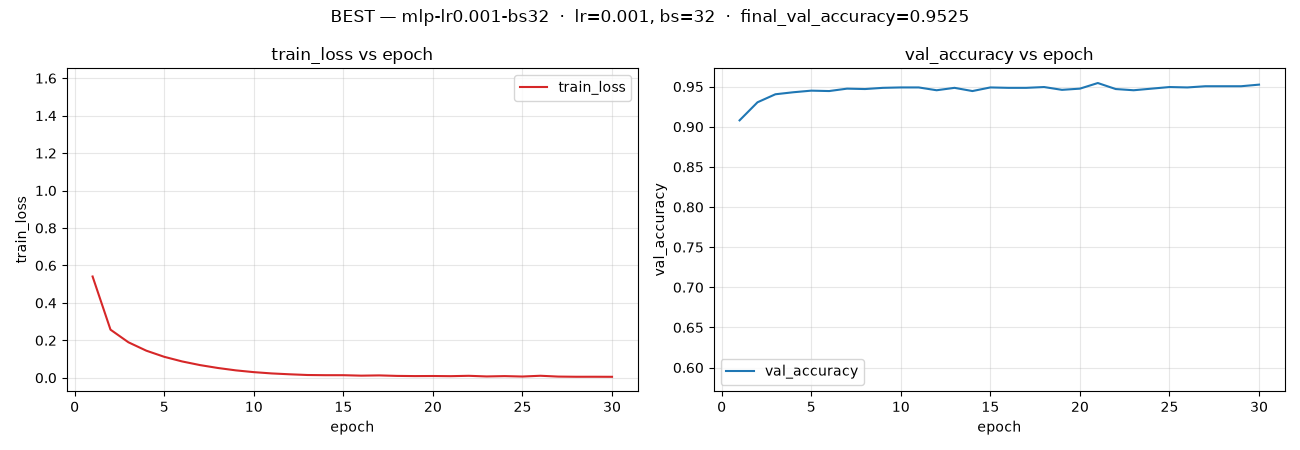

In [ ]:
fig, (ax_loss, ax_acc) = plt.subplots(1, 2, figsize=(13, 4.5))
plot_run_curves(ax_loss, ax_acc, best["run_id"], LOSS_YLIM, ACC_YLIM)
fig.suptitle(
    f"BEST — {best.get('tags.mlflow.runName', best['run_id'])}"
    f"  ·  lr={best['params.learning_rate']}, bs={best['params.batch_size']}"
    f"  ·  final_val_accuracy={float(best['metrics.final_val_accuracy']):.4f}"
)
fig.tight_layout()
plt.show()

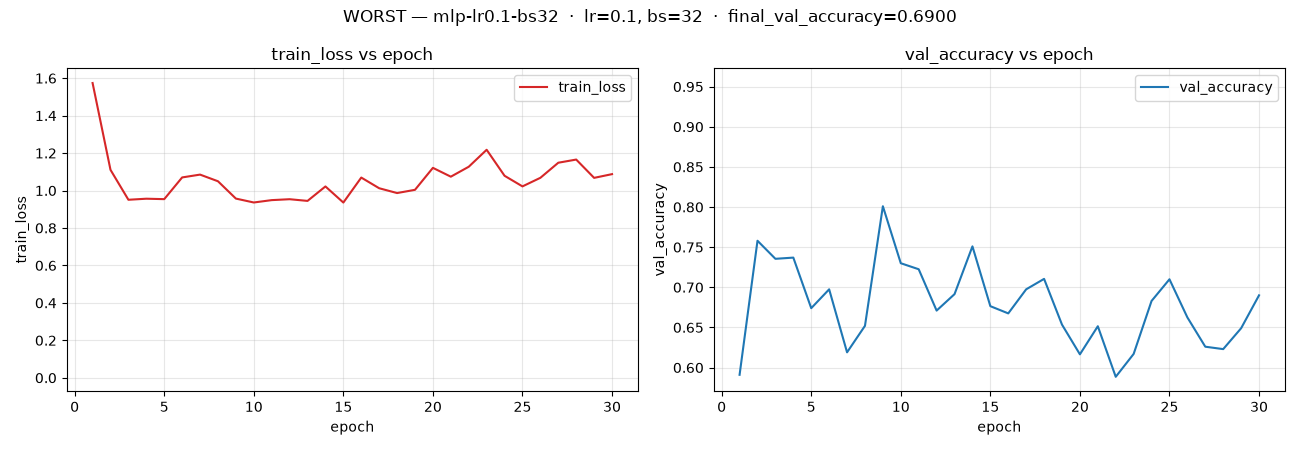

In [ ]:
fig, (ax_loss, ax_acc) = plt.subplots(1, 2, figsize=(13, 4.5))
plot_run_curves(ax_loss, ax_acc, worst["run_id"], LOSS_YLIM, ACC_YLIM)
fig.suptitle(
    f"WORST — {worst.get('tags.mlflow.runName', worst['run_id'])}"
    f"  ·  lr={worst['params.learning_rate']}, bs={worst['params.batch_size']}"
    f"  ·  final_val_accuracy={float(worst['metrics.final_val_accuracy']):.4f}"
)
fig.tight_layout()
plt.show()

## Step 6 — Which hyperparameter has the larger effect?
Two numbers rather than a qualitative read of the chart: the spread in `final_val_accuracy` across
all runs (learning-rate effect) against the mean absolute difference within each learning-rate pair
(batch-size effect).

In [ ]:
table = runs_table.assign(
    lr=runs_table["params.learning_rate"].astype(float),
    bs=runs_table["params.batch_size"].astype(int),
    acc=runs_table["metrics.final_val_accuracy"].astype(float),
)

lr_effect = table["acc"].max() - table["acc"].min()

pair_diffs = {}
for lr_value, group in table.groupby("lr"):
    if len(group) == 2:
        pair_diffs[lr_value] = abs(group["acc"].iloc[0] - group["acc"].iloc[1])
    else:
        print(f"note — learning_rate={lr_value} has {len(group)} run(s), not a pair; skipped")

bs_effect = sum(pair_diffs.values()) / len(pair_diffs) if pair_diffs else float("nan")

print("EFFECT SIZES (final_val_accuracy)")
print("─" * 52)
print(f"learning-rate effect  (max - min over all runs) : {lr_effect:.4f}")
print(f"batch-size effect     (mean |Δ| within lr pairs): {bs_effect:.4f}")
for lr_value, diff in sorted(pair_diffs.items()):
    print(f"    lr={lr_value:<6} |acc(bs=32) - acc(bs=256)| = {diff:.4f}")
print("─" * 52)
if lr_effect > bs_effect:
    print(f"→ LEARNING RATE has the larger effect ({lr_effect:.4f} vs {bs_effect:.4f}, "
          f"{lr_effect / bs_effect:.1f}x)" if bs_effect else "→ LEARNING RATE has the larger effect")
else:
    print(f"→ BATCH SIZE has the larger effect ({bs_effect:.4f} vs {lr_effect:.4f})")

print(f"\nBest run : lr={best['params.learning_rate']}, bs={best['params.batch_size']}, "
      f"final_val_accuracy={float(best['metrics.final_val_accuracy']):.4f}, "
      f"overfit_gap={float(best['metrics.overfit_gap']):.4f}")
print(f"Worst run: lr={worst['params.learning_rate']}, bs={worst['params.batch_size']}, "
      f"final_val_accuracy={float(worst['metrics.final_val_accuracy']):.4f}, "
      f"overfit_gap={float(worst['metrics.overfit_gap']):.4f}")

EFFECT SIZES (final_val_accuracy)
────────────────────────────────────────────────────
learning-rate effect  (max - min over all runs) : 0.2625
batch-size effect     (mean |Δ| within lr pairs): 0.0502
    lr=0.001  |acc(bs=32) - acc(bs=256)| = 0.0055
    lr=0.01   |acc(bs=32) - acc(bs=256)| = 0.0190
    lr=0.1    |acc(bs=32) - acc(bs=256)| = 0.1260
────────────────────────────────────────────────────
→ LEARNING RATE has the larger effect (0.2625 vs 0.0502, 5.2x)

Best run : lr=0.001, bs=32, final_val_accuracy=0.9525, overfit_gap=0.0463
Worst run: lr=0.1, bs=32, final_val_accuracy=0.6900, overfit_gap=0.0136


## Step 7 — Confirm in the MLflow UI
1. Go to **http://localhost:5000** in your browser.
2. Open the **mnist-mlp** experiment.
3. Select all 6 runs (checkboxes on the left) and click **Compare**.
4. Check that the run the UI ranks highest matches the best run from Step 4, and use the parallel
   coordinates plot to confirm the learning-rate effect found in Step 6.
5. Save the screenshot to `screenshots/`.

## Written Analysis (150–250 words)

_<write the analysis here — it must cover all three points below>_

1. **Best-performing run and why.** Name the winning `learning_rate` / `batch_size` combination from
   the Step 4 table and explain why it won — e.g. the step size was large enough to converge within
   30 epochs but small enough not to overshoot, and the batch size traded gradient noise against the
   number of updates per epoch.

2. **Overfitting evidence from the `train_loss` vs `val_accuracy` trend.** Cite the Step 5 curves and
   the `overfit_gap` column: point to where `train_loss` keeps falling while `val_accuracy` flattens
   or dips, and give the train/validation accuracy gap for the run that shows it most clearly.

3. **Which hyperparameter has the larger effect.** Quote the two numbers printed in Step 6
   (learning-rate effect vs batch-size effect) and state which dominates, rather than describing the
   chart qualitatively.

---
### ✅ Deliverable checklist
- [ ] `train.py` instrumented with params, per-epoch metrics, figure and model logging
- [ ] 6 runs logged to the `mnist-mlp` experiment (Step 3)
- [ ] Comparison table exported to `results/runs_export.csv` (Step 4)
- [ ] Best-vs-worst `train_loss` / `val_accuracy` plots (Step 5)
- [ ] Screenshot of the 6-run **Compare** view in the MLflow UI, saved under `screenshots/` (Step 7)
- [ ] 150–250 word written analysis covering all three points above